# Exercise 5: Create your own personal face recognition using SVM

## Instructions:

Create a directory in your google drive using this folder structure

```
My Drive
- Images
  - Train
    - Elizer
      - elizerimage1.jpg
      ...
    - Eliza
      - elizaimage1.jpg
      ...
    - Elijah
      - elijahimage1.jpg
      ...
  - Test
    - testimage1.jpg
    ...
```

- Upload 190 images of your self (selfied are recommended) in the Train folder
- Upload 190 images of your partner in the Train folder
- Upload 10 images each of yourself and your partner in the Test Folder (30 images total for each member)
- Use **.png** or **.jpg** or **.jpeg** images files

In [51]:
pip install numpy opencv-python scikit-learn

## Import libraries

In [52]:
import os
import cv2
import numpy as np
from PIL import Image  # PIL is used to load the image
import matplotlib.pyplot as plt

## Mount Google Drive

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Display one raw image directly from your drive

In [54]:
def displayImage(image_path):
  # Path to your image file in Google Drive
  image = Image.open(image_path)

  # Display the image using matplotlib
  plt.imshow(image)
  plt.axis('on')  # Hide axes for cleaner display
  plt.show()


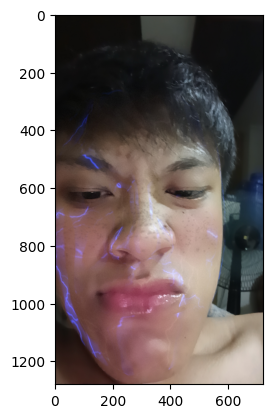

In [58]:
displayImage('/content/drive/My Drive/Images/Train/Ruiz, Mark/Snapchat-2118655367.jpg')

## 2. Load the images from your drive and apply preprocessing to your raw images

In [59]:
def load_images_from_folder(folder):
    images = []
    labels = []
    for label, person in enumerate(os.listdir(folder)):
        person_folder = os.path.join(folder, person)
        person_name = os.path.basename(person_folder)
        for filename in os.listdir(person_folder):
            img_path = os.path.join(person_folder, filename)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
            img = cv2.resize(img, (100, 100))  # Resize to 100x100 pixels
            images.append(img.flatten())  # Flatten the image
            labels.append(person_name)
    return images, labels

In [60]:
images, labels = load_images_from_folder('/content/drive/My Drive/Images/Train')

In [61]:
images = np.array(images)
print(images.shape)

(385, 10000)


In [62]:
labels = np.array(labels)
labels.shape

(385,)

In [63]:
labels

array(['Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genesis',
       'Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genesis',
       'Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genesis',
       'Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genesis',
       'Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genesis',
       'Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genesis',
       'Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genesis',
       'Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genesis',
       'Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genesis',
       'Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genesis',
       'Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genesis',
       'Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genesis',
       'Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genesis',
       'Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genesis',
       'Navarro, Genesis', 'Navarro, Genesis', 'Navarro, Genes

## 3. Display one pre-processed image from the training set

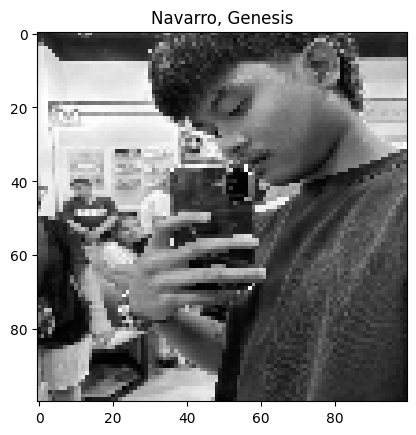

In [64]:
# Get a sample image and its corresponding name
image = images[0].reshape(100,100)  # Access the first image
name = labels[0]  # Get the name corresponding to the image

# Display the image
plt.imshow(image, cmap="gray")
plt.title(name)
plt.axis('on')  # Hide axes
plt.show()

## 4. Display ten pre-processed images from the training set

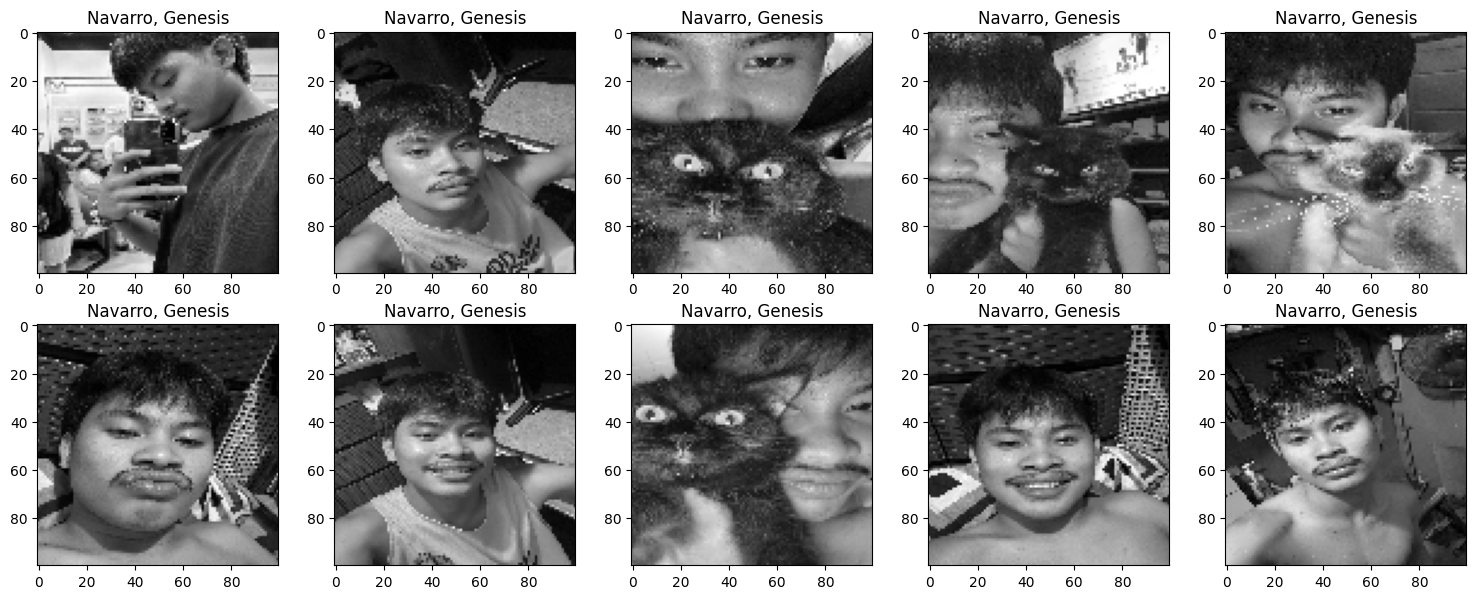

In [65]:
num_faces = 10

fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # 2 rows and 5 columns
axes = axes.flatten()  # Flatten the array of axes for easy indexing

# Loop to display the images
for i in range(num_faces):
    image = images[i].reshape(100,100)  # Access the i-th image
    name = labels[i]  # Get the name corresponding to the image

    axes[i].imshow(image, cmap='gray')  # Show the image
    axes[i].set_title(name)  # Set the title to the name
    axes[i].axis('on')  # Hide axes

# Adjust layout
plt.tight_layout()
plt.show()



## 5. Split your training data

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

## 6. Train your SVM model

In [67]:
from sklearn import svm

model = svm.SVC(gamma='scale')
model.fit(X_train, y_train)

SVC()

## 7. Evaluate your SVM model

In [68]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 98.70%


## 8. Test your model using images not in your training set

Use your SVM model to predict the label of all of your images in the Test folder

In [69]:
def predict_image(img_path, model):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not load image from {img_path}")
        return None # Return None to indicate failure
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (100, 100)).flatten().reshape(1, -1)  # Flatten and reshape for prediction
    prediction = model.predict(img)
    return prediction

Predicted label: ['Navarro, Genesis']


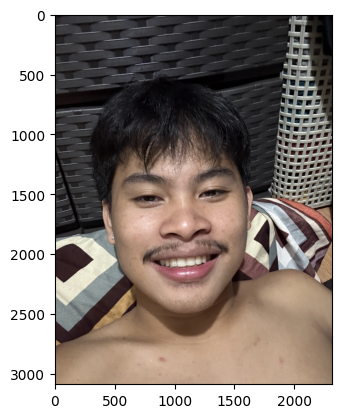

In [70]:
img_path = ('/content/drive/My Drive/Images/Test/Ruiz, Mark/1.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Navarro, Genesis']


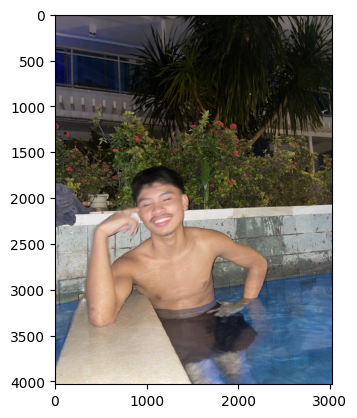

In [72]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/2.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Navarro, Genesis']


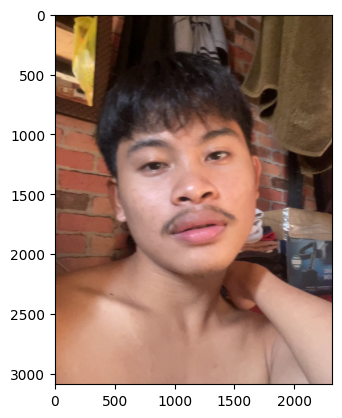

In [71]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/3 (1).jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Ruiz, Mark']


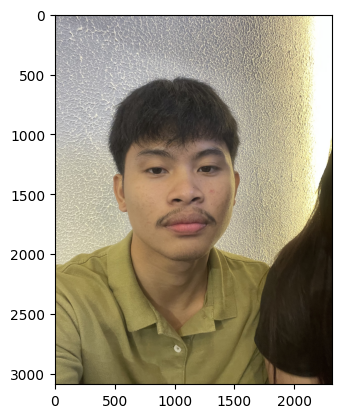

In [73]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/3.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Navarro, Genesis']


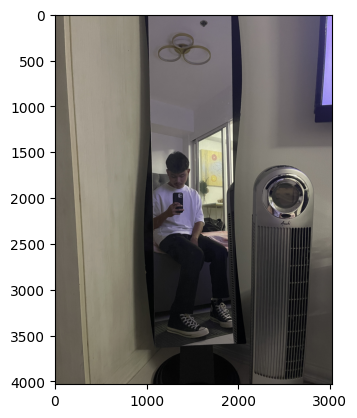

In [74]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/4.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Navarro, Genesis']


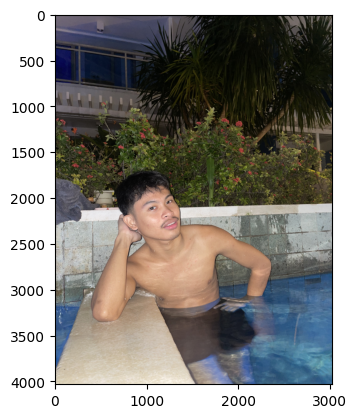

In [75]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/5.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Navarro, Genesis']


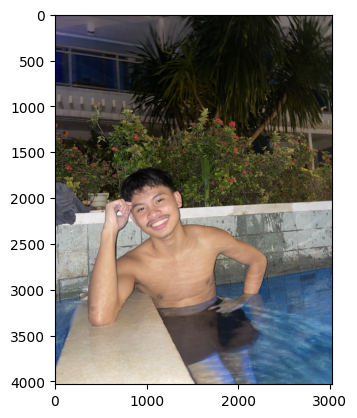

In [76]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/6.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Navarro, Genesis']


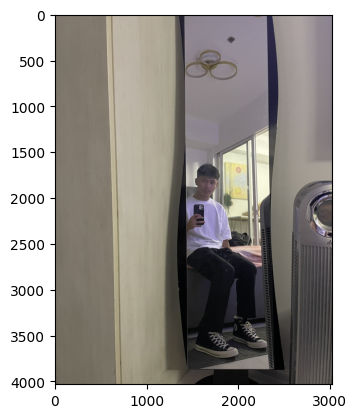

In [77]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/7.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Navarro, Genesis']


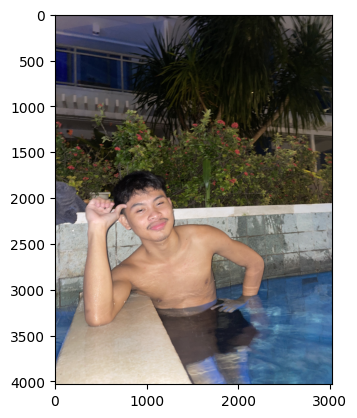

In [78]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/8.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Navarro, Genesis']


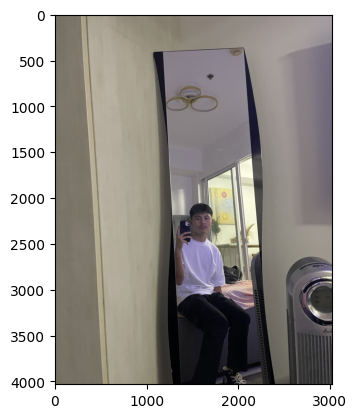

In [79]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/9.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Medio, Charles']


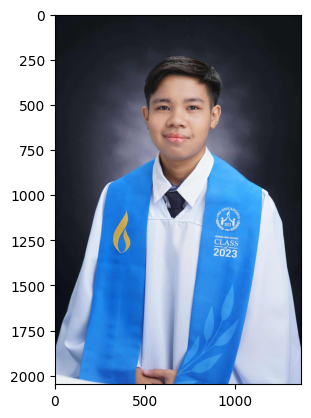

In [80]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/20.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Medio, Charles']


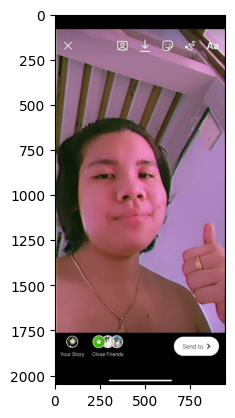

In [81]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/21.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Ruiz, Mark']


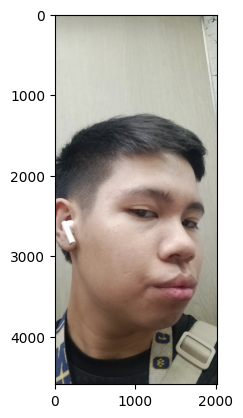

In [82]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/22.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Navarro, Genesis']


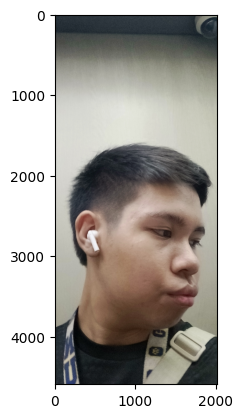

In [83]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/28.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Medio, Charles']


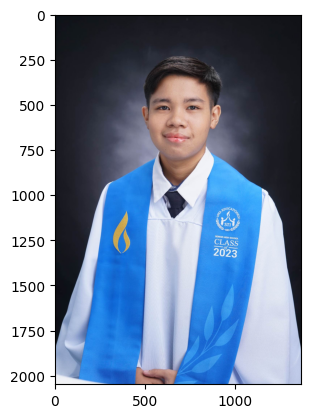

In [84]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/29.jpeg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Ruiz, Mark']


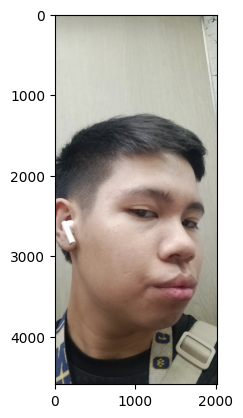

In [85]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/23.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Navarro, Genesis']


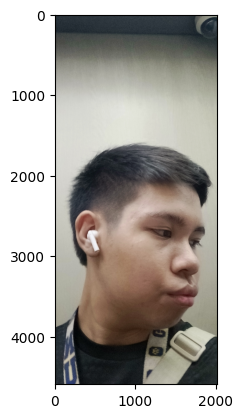

In [86]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/24.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Medio, Charles']


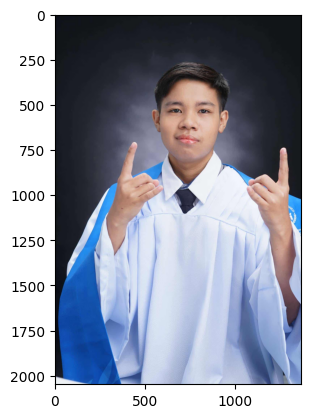

In [87]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/25.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Ruiz, Mark']


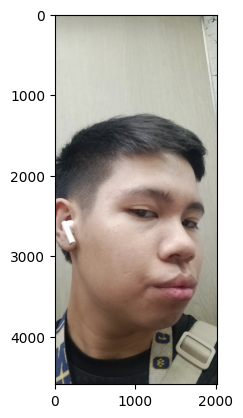

In [88]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/26.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Navarro, Genesis']


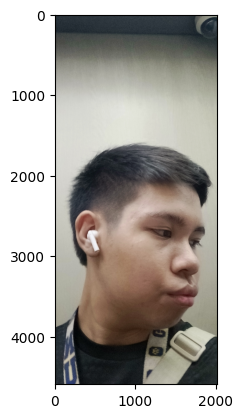

In [89]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/27.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Ruiz, Mark']


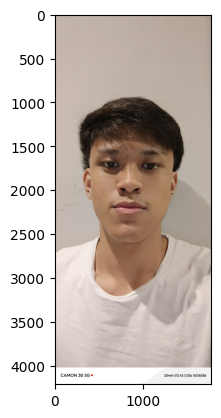

In [90]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/10.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Ruiz, Mark']


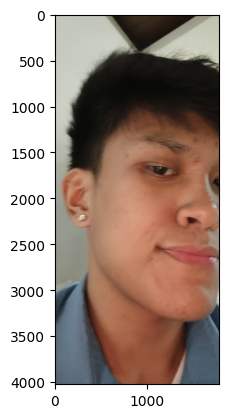

In [91]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/11.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Ruiz, Mark']


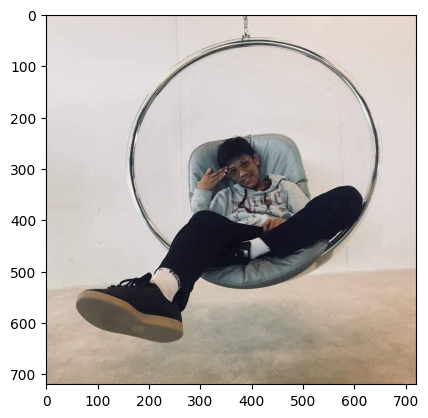

In [92]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/12.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Ruiz, Mark']


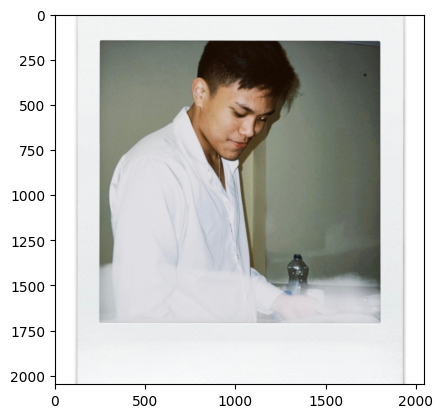

In [93]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/13.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Ruiz, Mark']


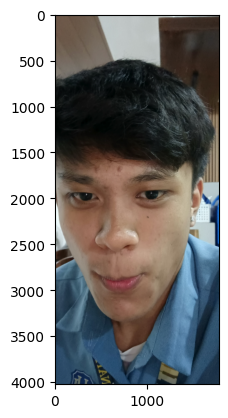

In [94]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/14.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Navarro, Genesis']


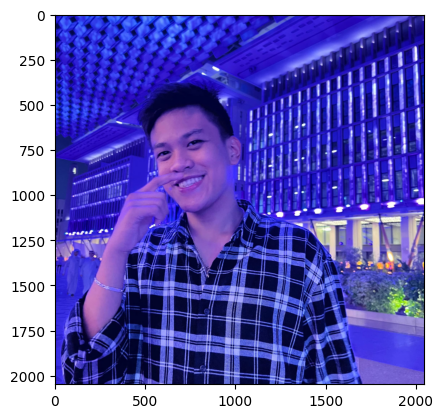

In [95]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/15.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Navarro, Genesis']


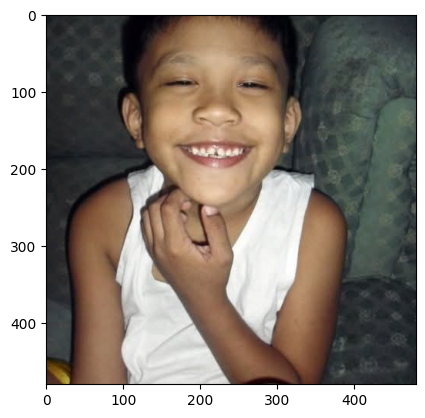

In [96]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/16.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Ruiz, Mark']


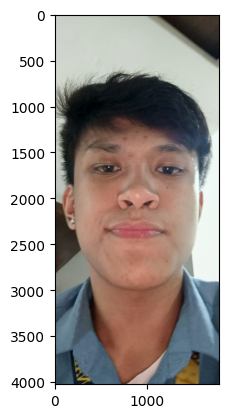

In [97]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/17.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Ruiz, Mark']


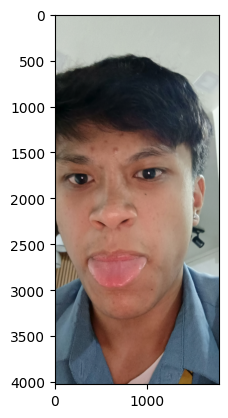

In [98]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/18.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)

Predicted label: ['Navarro, Genesis']


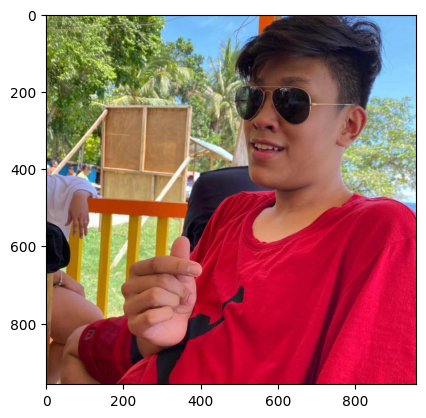

In [99]:
img_path = ('/content/drive/MyDrive/Images/Test/Ruiz, Mark/19.jpg')
result = predict_image(img_path, model)
print(f'Predicted label:', result)
displayImage(img_path)